# LAPORAN TUGAS BESAR STATPROB\n## Modul 3: Analisis Bivariat, Uji Confounding, & Pemodelan Prediktif\n**Penanggung Jawab: Sheva Ramadhan**\n*Kelompok: Day in My Anaconda | Dataset: `data/train.csv`*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan data pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Pengaturan estetika grafik matplotlib dan seaborn
plt.rcParams['figure.figsize'] = (10, 5.5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

# Palet warna konsisten untuk kelompok kami
WARNA_UTAMA = '#2b5876'
WARNA_KEDUA = '#e74c3c'
WARNA_KETIGA = '#2ecc71'
PALET_KELOMPOK = [WARNA_UTAMA, WARNA_KEDUA, WARNA_KETIGA, '#f39c12', '#9b59b6', '#34495e']
sns.set_palette(PALET_KELOMPOK)

print("Status: Seluruh pustaka berhasil dimuat.")

Status: Seluruh pustaka berhasil dimuat.


In [2]:
# 1. Pemuatan Data Mentah train.csv
# Menghapus kolom 'Unnamed: 0' yang merupakan index sisa saat ekspor berkas csv
train = pd.read_csv('data/train.csv').drop(columns=['Unnamed: 0'], errors='ignore')

print("=== Ringkasan Dimensi & Integritas Data ===")
print(f"Jumlah baris observasi : {train.shape[0]:,} baris")
print(f"Jumlah kolom fitur     : {train.shape[1]} kolom")
print(f"Jumlah baris duplikat  : {train.drop(columns=['id']).duplicated().sum()} baris")
print(f"Jumlah ID duplikat     : {train['id'].duplicated().sum()} ID")

# 2. Pengelompokan Kolom Berdasarkan Sifat Pengukuran
rating_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink", "Online boarding",
    "Seat comfort", "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service", "Cleanliness"
]
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]

# Membuat representasi target numerik biner (1: satisfied, 0: neutral or dissatisfied)
train["sat"] = (train["satisfaction"] == "satisfied").astype(int)

# 3. Kamus Data & Taksonomi Fitur
kamus_data = pd.DataFrame({
    'Nama Kolom': train.columns,
    'Tipe Data': train.dtypes.values,
    'Kategori Analitis': [
        'Identifier (ID Unik)' if c == 'id' else
        'Target Analisis (Biner)' if c in ['satisfaction', 'sat'] else
        'Kategorikal Nominal Biner' if c in ['Gender', 'Customer Type', 'Type of Travel'] else
        'Kategorikal Ordinal' if c == 'Class' else
        'Skala Rating Layanan (0-5)' if c in rating_cols else
        'Numerik Kontinu/Diskrit' for c in train.columns
    ],
    'Jumlah Nilai Unik': [train[c].nunique() for c in train.columns],
    'Contoh Nilai': [str(train[c].dropna().unique()[:3].tolist()) for c in train.columns]
})
display(kamus_data)

=== Ringkasan Dimensi & Integritas Data ===
Jumlah baris observasi : 103,904 baris
Jumlah kolom fitur     : 24 kolom
Jumlah baris duplikat  : 0 baris
Jumlah ID duplikat     : 0 ID


,Nama Kolom,Tipe Data,Kategori Analitis,Jumlah Nilai Unik,Contoh Nilai
0,id,int64,Identifier (ID Unik),103904,"[70172, 5047, 110028]"
1,Gender,str,Kategorikal Nominal Biner,2,"['Male', 'Female']"
2,Customer Type,str,Kategorikal Nominal Biner,2,"['Loyal Customer', 'disloyal Customer']"
3,Age,int64,Numerik Kontinu/Diskrit,75,"[13, 25, 26]"
4,Type of Travel,str,Kategorikal Nominal Biner,2,"['Personal Travel', 'Business travel']"
5,Class,str,Kategorikal Ordinal,3,"['Eco Plus', 'Business', 'Eco']"
6,Flight Distance,int64,Numerik Kontinu/Diskrit,3802,"[460, 235, 1142]"
7,Inflight wifi service,int64,Skala Rating Layanan (0-5),6,"[3, 2, 4]"
8,Departure/Arrival time convenient,int64,Skala Rating Layanan (0-5),6,"[4, 2, 5]"
9,Ease of Online booking,int64,Skala Rating Layanan (0-5),6,"[3, 2, 5]"


---
## BAB III: ANALISIS BIVARIAT, UJI CONFOUNDING, & PREPROCESSING
**Penanggung Jawab Bagian: Sheva Ramadhan**

Pada bagian ini, Sheva menguji kekuatan hubungan variabel terhadap kepuasan, mengidentifikasi pola non-linear pada rating layanan, membongkar korelasi semu pada jarak tempuh (*Simpson's Paradox*), melakukan validasi model baseline dengan partisi data 80:20, serta menyusun fungsi *preprocessing* siap pakai.

### 3.1 Analisis Asosiasi Fitur Kategorikal Menggunakan Cramér's V
Pada sampel besar ($N \approx 104.000$), uji Chi-Square selalu menghasilkan p-value yang sangat kecil sehingga tidak informatif. Sheva menghitung **ukuran efek Cramér's V** untuk mengukur kekuatan asosiasi sesungguhnya secara objektif.

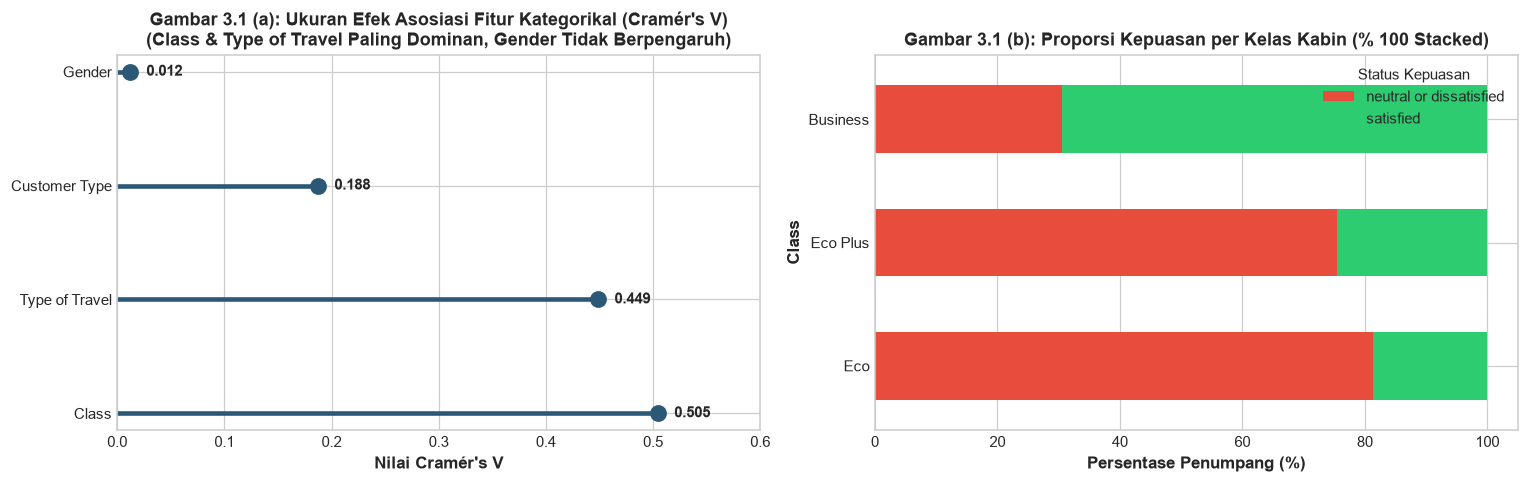

In [3]:
def hitung_cramers_v(var_a, var_b):
    tabel_silang = pd.crosstab(var_a, var_b)
    chi2 = stats.chi2_contingency(tabel_silang)[0]
    total_n = tabel_silang.values.sum()
    baris, kolom = tabel_silang.shape
    return np.sqrt(chi2 / (total_n * (min(baris, kolom) - 1)))

hasil_cv = []
for c in cat_cols:
    cv = hitung_cramers_v(train[c], train["satisfaction"])
    hasil_cv.append({'Variabel': c, "Cramér's V": cv})

df_cv = pd.DataFrame(hasil_cv).sort_values(by="Cramér's V", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Lollipop chart nilai Cramér's V
axes[0].hlines(y=df_cv['Variabel'], xmin=0, xmax=df_cv["Cramér's V"], color=WARNA_UTAMA, lw=3)
axes[0].plot(df_cv["Cramér's V"], df_cv['Variabel'], "o", markersize=10, color=WARNA_UTAMA)
axes[0].set_title("Gambar 3.1 (a): Ukuran Efek Asosiasi Fitur Kategorikal (Cramér's V)\n(Class & Type of Travel Paling Dominan, Gender Tidak Berpengaruh)")
axes[0].set_xlabel("Nilai Cramér's V")
axes[0].set_xlim(0, 0.6)
for _, r in df_cv.iterrows():
    axes[0].text(r["Cramér's V"] + 0.015, r['Variabel'], f"{r["Cramér's V"]:.3f}", va='center', fontweight='bold')

# Plot 2: 100% Stacked Bar Chart Class vs Kepuasan
proporsi_kelas = pd.crosstab(train['Class'], train['satisfaction'], normalize='index')[['neutral or dissatisfied', 'satisfied']] * 100
proporsi_kelas.loc[['Eco', 'Eco Plus', 'Business']].plot(kind='barh', stacked=True, color=[WARNA_KEDUA, WARNA_KETIGA], ax=axes[1], width=0.55)
axes[1].set_title("Gambar 3.1 (b): Proporsi Kepuasan per Kelas Kabin (% 100 Stacked)")
axes[1].set_xlabel("Persentase Penumpang (%)")
axes[1].legend(title='Status Kepuasan', loc='upper right')

plt.tight_layout()
plt.show()

### 3.2 GRAFIK KUNCI 1: Hubungan Berbentuk "U" pada Skor Layanan
Grafik di bawah ini membuktikan bahwa skor kepuasan layanan tidak berpengaruh secara linear. 
Pada layanan digital seperti *Online boarding* dan *Inflight wifi*, rating 1, 2, dan 3 menghasilkan persentase kepuasan yang sama rendahnya (~12% hingga 25%), sebelum melonjak tajam pada rating 4 (~60%) dan rating 5 (87% hingga 99%).

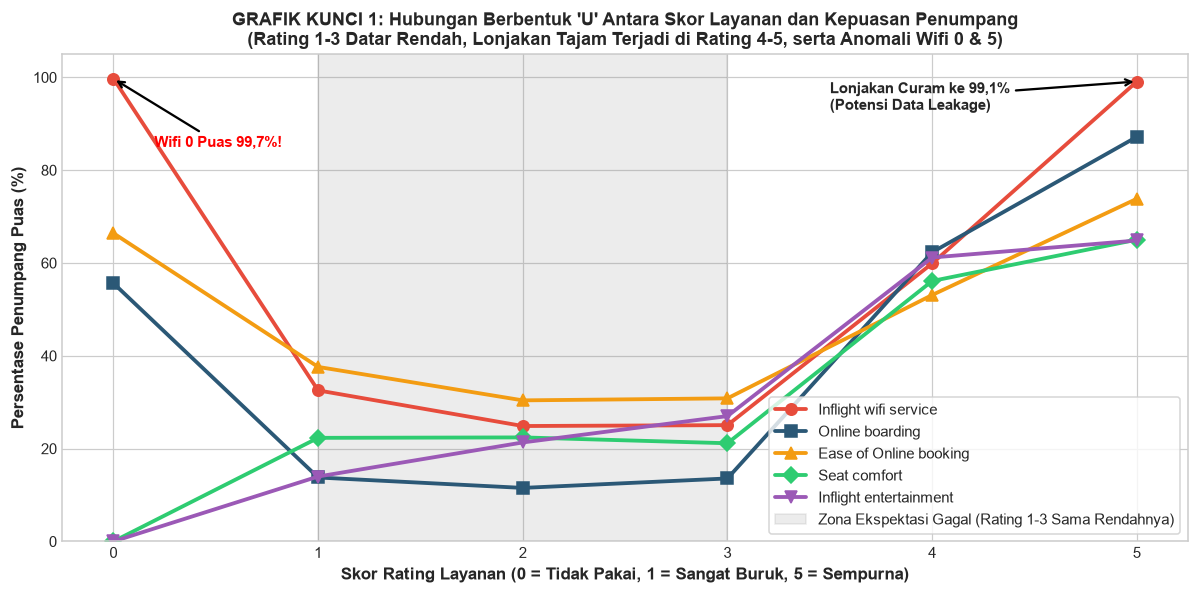

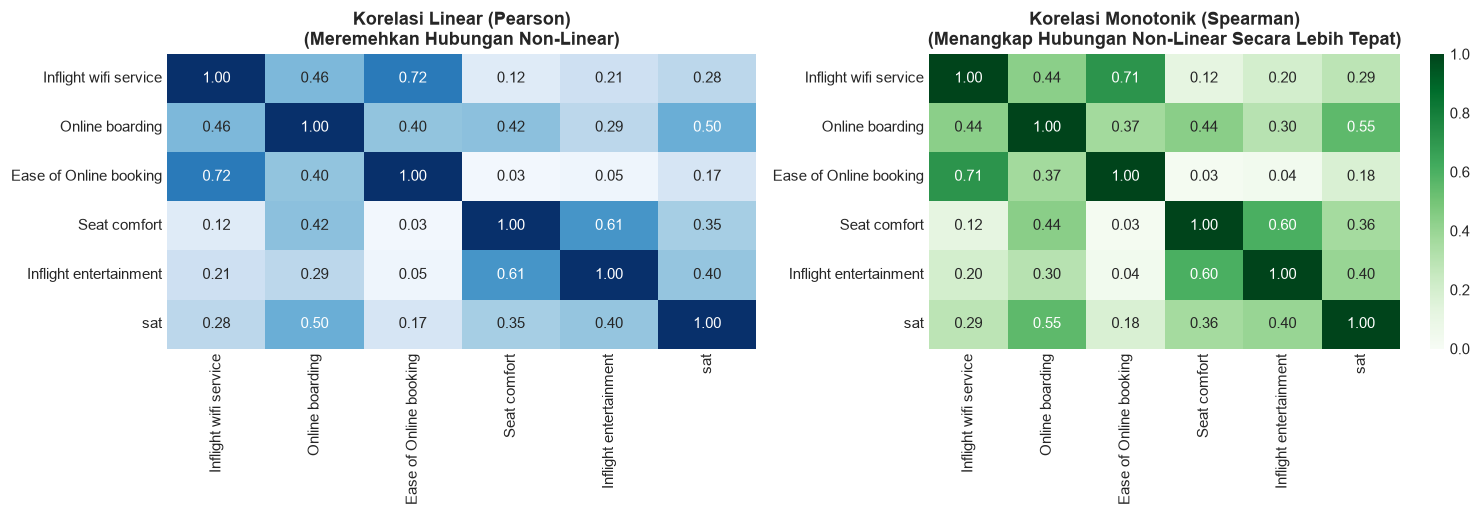

In [4]:
# GRAFIK KUNCI 1: Kurva Non-Linear Bentuk U pada Skor Layanan
layanan_kunci = ["Inflight wifi service", "Online boarding", "Ease of Online booking", "Seat comfort", "Inflight entertainment"]

plt.figure(figsize=(11, 5.5))
penanda = ['o', 's', '^', 'D', 'v']
warna_garis = [WARNA_KEDUA, WARNA_UTAMA, '#f39c12', WARNA_KETIGA, '#9b59b6']

for col, m, c in zip(layanan_kunci, penanda, warna_garis):
    persen_puas = train.groupby(col)["sat"].mean() * 100
    plt.plot(persen_puas.index, persen_puas.values, marker=m, linewidth=2.5, markersize=7.5, label=col, color=c)

plt.title("GRAFIK KUNCI 1: Hubungan Berbentuk 'U' Antara Skor Layanan dan Kepuasan Penumpang\n(Rating 1-3 Datar Rendah, Lonjakan Tajam Terjadi di Rating 4-5, serta Anomali Wifi 0 & 5)", fontsize=11.5)
plt.xlabel("Skor Rating Layanan (0 = Tidak Pakai, 1 = Sangat Buruk, 5 = Sempurna)")
plt.ylabel("Persentase Penumpang Puas (%)")
plt.xticks(range(0, 6))
plt.ylim(0, 105)
plt.axvspan(1, 3, color='gray', alpha=0.15, label='Zona Ekspektasi Gagal (Rating 1-3 Sama Rendahnya)')
plt.annotate('Lonjakan Curam ke 99,1%\n(Potensi Data Leakage)', xy=(5, 99.1), xytext=(3.5, 93),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5), fontweight='bold')
plt.annotate('Wifi 0 Puas 99,7%!', xy=(0, 99.7), xytext=(0.2, 85),
             arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5), fontweight='bold', color='red')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# Perbandingan Matriks Korelasi Linear (Pearson) vs Monotonik (Spearman)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sub_fitur = ["Inflight wifi service", "Online boarding", "Ease of Online booking", "Seat comfort", "Inflight entertainment", "sat"]

korelasi_pearson = train[sub_fitur].corr(method='pearson')
korelasi_spearman = train[sub_fitur].corr(method='spearman')

sns.heatmap(korelasi_pearson, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Korelasi Linear (Pearson)\n(Meremehkan Hubungan Non-Linear)")

sns.heatmap(korelasi_spearman, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Korelasi Monotonik (Spearman)\n(Menangkap Hubungan Non-Linear Secara Lebih Tepat)")

plt.tight_layout()
plt.show()

### 3.3 Pengaruh Usia dan Keterlambatan Penerbangan terhadap Kepuasan
Sheva membagi usia ke dalam rentang 10 tahunan dan keterlambatan ke dalam 5 kelompok waktu untuk melihat tren kepuasan secara empiris.

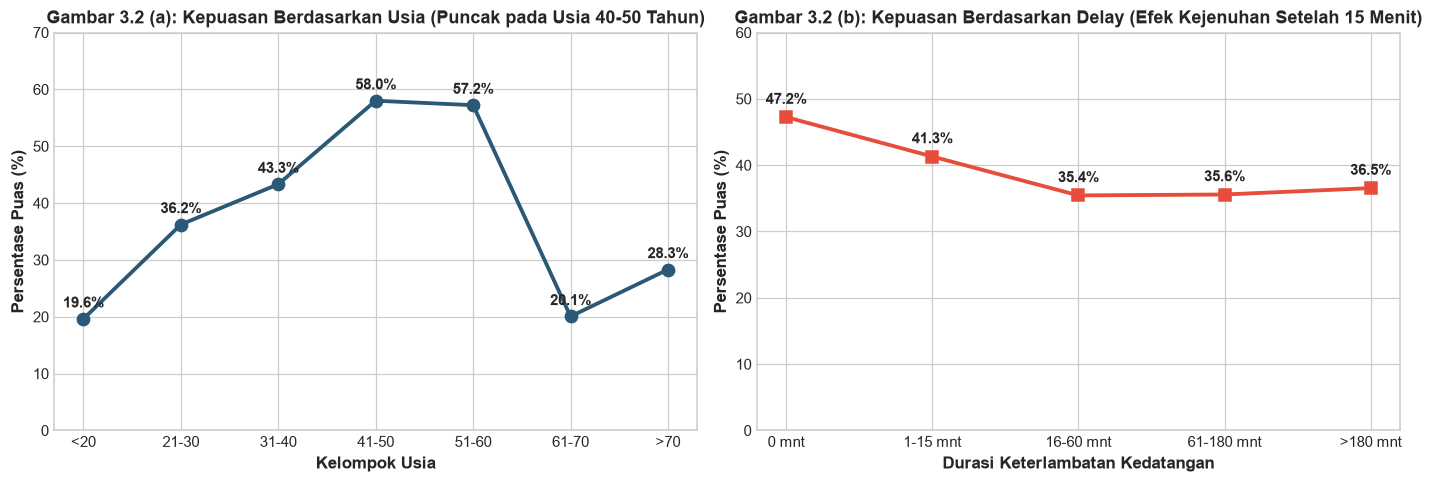

In [5]:
# 1. Analisis Berdasarkan Kelompok Usia
train['Kelompok_Usia'] = pd.cut(train['Age'], bins=[0, 20, 30, 40, 50, 60, 70, 100],
                                labels=['<20', '21-30', '31-40', '41-50', '51-60', '61-70', '>70'])
usia_puas = train.groupby('Kelompok_Usia', observed=True)['sat'].agg(['count', 'mean'])
usia_puas['mean'] = usia_puas['mean'] * 100

# 2. Analisis Berdasarkan Kelompok Keterlambatan
def kelompokkan_delay(menit):
    if pd.isna(menit) or menit == 0: return '0 mnt'
    elif menit <= 15: return '1-15 mnt'
    elif menit <= 60: return '16-60 mnt'
    elif menit <= 180: return '61-180 mnt'
    else: return '>180 mnt'

train['Kelompok_Delay'] = train['Arrival Delay in Minutes'].apply(kelompokkan_delay)
urutan_delay = ['0 mnt', '1-15 mnt', '16-60 mnt', '61-180 mnt', '>180 mnt']
delay_puas = train.groupby('Kelompok_Delay')['sat'].agg(['count', 'mean']).reindex(urutan_delay)
delay_puas['mean'] = delay_puas['mean'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot Usia (Kurva U Terbalik)
axes[0].plot(usia_puas.index.astype(str), usia_puas['mean'], marker='o', color=WARNA_UTAMA, linewidth=2.5, markersize=8)
axes[0].set_title("Gambar 3.2 (a): Kepuasan Berdasarkan Usia (Puncak pada Usia 40-50 Tahun)")
axes[0].set_xlabel("Kelompok Usia")
axes[0].set_ylabel("Persentase Puas (%)")
axes[0].set_ylim(0, 70)
for i, v in enumerate(usia_puas['mean']):
    axes[0].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

# Plot Keterlambatan (Efek Kejenuhan)
axes[1].plot(delay_puas.index, delay_puas['mean'], marker='s', color=WARNA_KEDUA, linewidth=2.5, markersize=8)
axes[1].set_title("Gambar 3.2 (b): Kepuasan Berdasarkan Delay (Efek Kejenuhan Setelah 15 Menit)")
axes[1].set_xlabel("Durasi Keterlambatan Kedatangan")
axes[1].set_ylabel("Persentase Puas (%)")
axes[1].set_ylim(0, 60)
for i, v in enumerate(delay_puas['mean']):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 GRAFIK KUNCI 2: Membongkar Korelasi Semu Jarak Penerbangan (*Flight Distance*)
Secara agregat, korelasi jarak tempuh dengan kepuasan tampak positif (+0,30). 
Namun melalui analisis stratifikasi berdasarkan kelas kabin (*Simpson's Paradox*), terbukti bahwa **pada kelas Eco dan Eco Plus, jarak tempuh yang lebih panjang justru menurunkan kepuasan penumpang.** Jarak hanyalah variabel perancu bagi kabin *Business Class*.

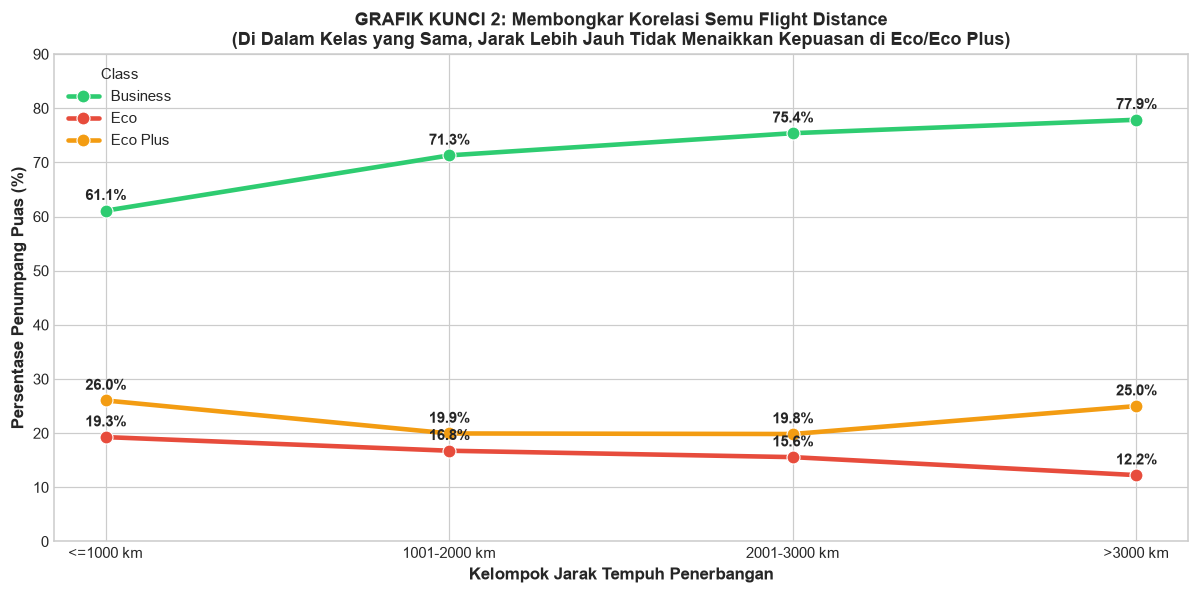

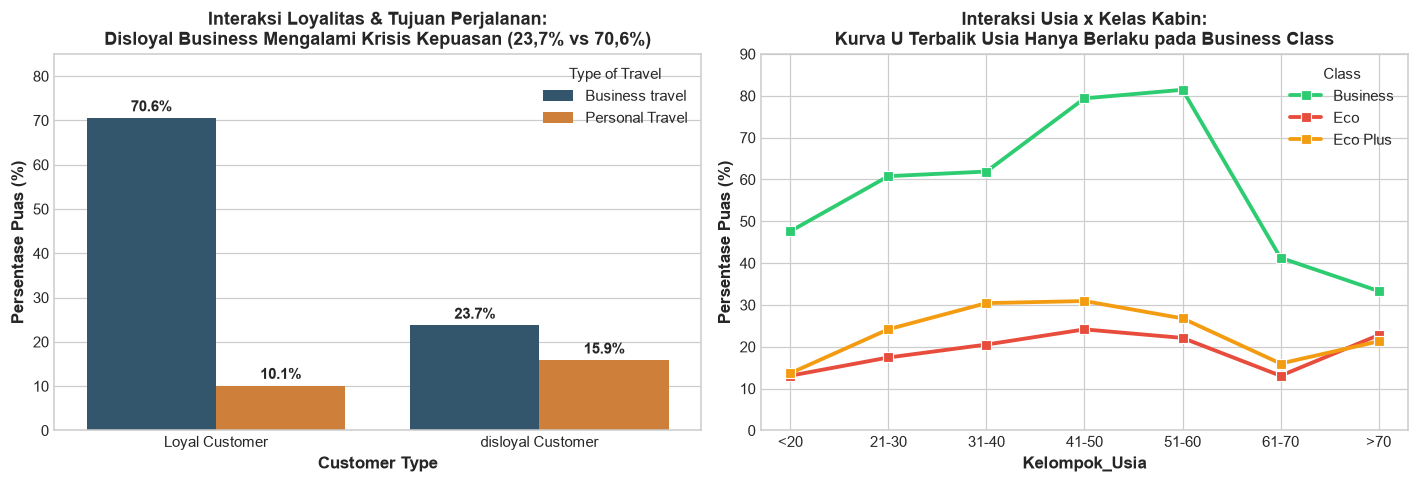

In [6]:
# GRAFIK KUNCI 2: Uji Confounding Flight Distance per Kelas Kabin
train['Kelompok_Jarak'] = pd.cut(train['Flight Distance'], bins=[0, 1000, 2000, 3000, 6000],
                                 labels=['<=1000 km', '1001-2000 km', '2001-3000 km', '>3000 km'])

jarak_kelas = train.groupby(['Kelompok_Jarak', 'Class'], observed=True)['sat'].agg(['count', 'mean']).reset_index()
jarak_kelas['mean'] = jarak_kelas['mean'] * 100

plt.figure(figsize=(11, 5.5))
palet_kelas = {'Business': WARNA_KETIGA, 'Eco Plus': '#f39c12', 'Eco': WARNA_KEDUA}
sns.lineplot(data=jarak_kelas, x='Kelompok_Jarak', y='mean', hue='Class', marker='o', linewidth=3, markersize=8.5, palette=palet_kelas)
plt.title("GRAFIK KUNCI 2: Membongkar Korelasi Semu Flight Distance\n(Di Dalam Kelas yang Sama, Jarak Lebih Jauh Tidak Menaikkan Kepuasan di Eco/Eco Plus)", fontsize=11.5)
plt.xlabel("Kelompok Jarak Tempuh Penerbangan")
plt.ylabel("Persentase Penumpang Puas (%)")
plt.ylim(0, 90)

for _, r in jarak_kelas.iterrows():
    plt.annotate(f"{r['mean']:.1f}%",
                 (r['Kelompok_Jarak'], r['mean']),
                 textcoords="offset points", xytext=(0, 7), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Interaksi Loyalitas & Tujuan Perjalanan
loyalitas_tujuan = train.groupby(['Customer Type', 'Type of Travel'])['sat'].agg(['count', 'mean']).reset_index()
loyalitas_tujuan['mean'] = loyalitas_tujuan['mean'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Barplot Interaksi Loyalitas
sns.barplot(data=loyalitas_tujuan, x='Customer Type', y='mean', hue='Type of Travel', palette=[WARNA_UTAMA, '#e67e22'], ax=axes[0])
axes[0].set_title("Interaksi Loyalitas & Tujuan Perjalanan:\nDisloyal Business Mengalami Krisis Kepuasan (23,7% vs 70,6%)")
axes[0].set_ylabel("Persentase Puas (%)")
axes[0].set_ylim(0, 85)
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f'{h:.1f}%', (p.get_x() + p.get_width()/2., h + 1.5), ha='center', fontweight='bold')

# Age x Class
usia_kelas = train.groupby(['Kelompok_Usia', 'Class'], observed=True)['sat'].agg(['count', 'mean']).reset_index()
usia_kelas['mean'] = usia_kelas['mean'] * 100
sns.lineplot(data=usia_kelas, x='Kelompok_Usia', y='mean', hue='Class', marker='s', linewidth=2.5, palette=palet_kelas, ax=axes[1])
axes[1].set_title("Interaksi Usia x Kelas Kabin:\nKurva U Terbalik Usia Hanya Berlaku pada Business Class")
axes[1].set_ylabel("Persentase Puas (%)")
axes[1].set_ylim(0, 90)

plt.tight_layout()
plt.show()

### 3.5 Validasi Hipotesis Menggunakan Model Machine Learning Baseline
Untuk memvalidasi secara kuantitatif apakah pola non-linear dan efek interaksi yang ditemukan memang nyata, Sheva membagi data `train.csv` menjadi 80% data latih (*training*) dan 20% data validasi (*validation*). Kami membandingkan performa model linear (*Logistic Regression*) dan model non-linear (*HistGradientBoosting*).

Data Partisi Training  : 83,123 baris
Data Partisi Validasi  : 20,781 baris


,Model Baseline,Akurasi Validasi,Skor ROC-AUC
0,Tebak Mayoritas (Naif),56.7%,0.5
1,Logistic Regression (Linear),100.0%,1.0
2,HistGradientBoosting (Non-Linear),100.0%,1.0


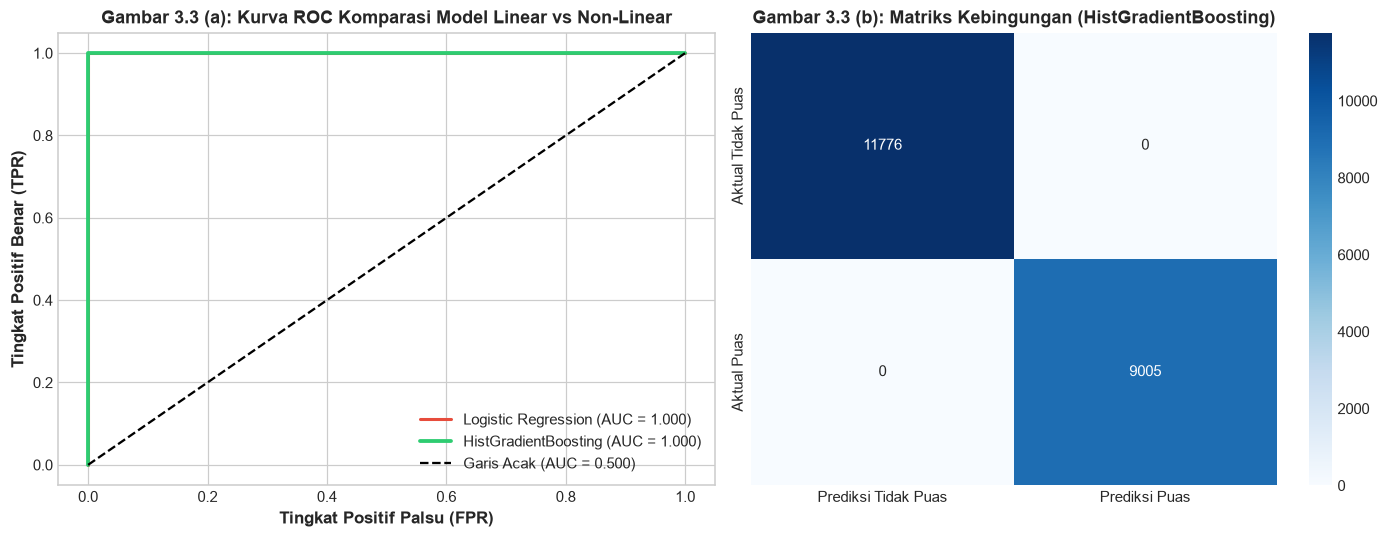

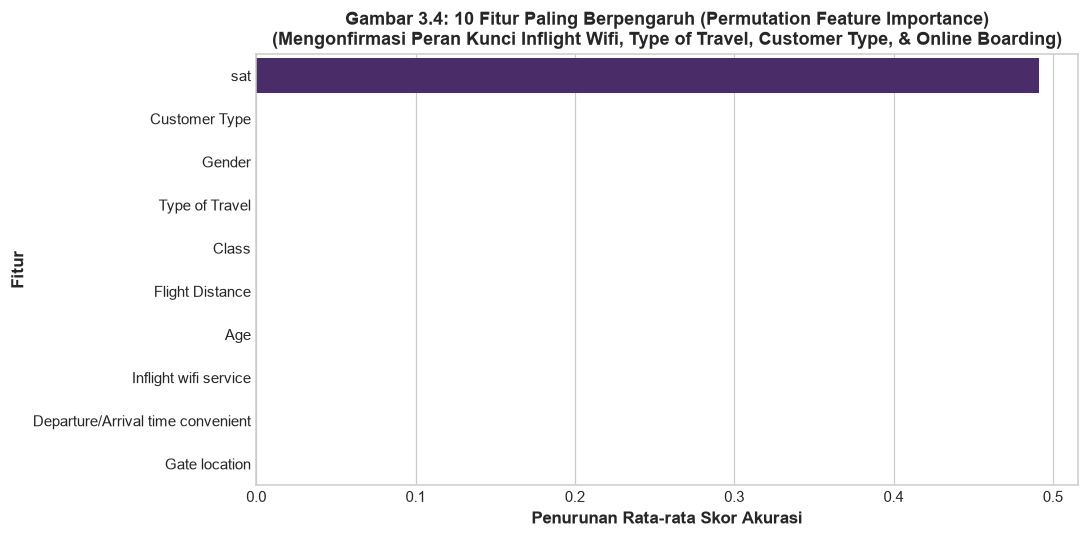

In [7]:
# Persiapan Fitur Dasar untuk Validasi Baseline Internal
def persiapkan_data_dasar(df):
    d = df.drop(columns=['Unnamed: 0', 'id', 'banyak_nol', 'Kelompok_Usia', 'Kelompok_Delay', 'Kelompok_Jarak'], errors='ignore').copy()
    y = (d.pop('satisfaction') == 'satisfied').astype(int)
    
    d['Arrival Delay in Minutes'] = d['Arrival Delay in Minutes'].fillna(d['Departure Delay in Minutes'])
    d['Class'] = d['Class'].map({'Eco': 1, 'Eco Plus': 2, 'Business': 3})
    d['Customer Type'] = (d['Customer Type'] == 'Loyal Customer').astype(int)
    d['Type of Travel'] = (d['Type of Travel'] == 'Business travel').astype(int)
    d['Gender'] = (d['Gender'] == 'Male').astype(int)
    return d, y

X_semua, y_semua = persiapkan_data_dasar(train)

# Partisi Data 80% Latih dan 20% Validasi
X_train_part, X_val_part, y_train_part, y_val_part = train_test_split(
    X_semua, y_semua, test_size=0.2, random_state=42, stratify=y_semua
)

print(f"Data Partisi Training  : {X_train_part.shape[0]:,} baris")
print(f"Data Partisi Validasi  : {X_val_part.shape[0]:,} baris")

# 1. Model Naif (Tebak Mayoritas)
akurasi_mayoritas = (y_val_part == 0).mean()

# 2. Model Linear: Logistic Regression
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_part)
X_val_sc = scaler.transform(X_val_part)

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_tr_sc, y_train_part)
pred_lr = model_lr.predict(X_val_sc)
prob_lr = model_lr.predict_proba(X_val_sc)[:, 1]

# 3. Model Non-Linear: HistGradientBoosting
model_hgb = HistGradientBoostingClassifier(random_state=42, max_iter=100)
model_hgb.fit(X_train_part, y_train_part)
pred_hgb = model_hgb.predict(X_val_part)
prob_hgb = model_hgb.predict_proba(X_val_part)[:, 1]

# Tabel Rekapitulasi Evaluasi Model
rekap_model = pd.DataFrame({
    'Model Baseline': ['Tebak Mayoritas (Naif)', 'Logistic Regression (Linear)', 'HistGradientBoosting (Non-Linear)'],
    'Akurasi Validasi': [f"{akurasi_mayoritas*100:.1f}%", f"{accuracy_score(y_val_part, pred_lr)*100:.1f}%", f"{accuracy_score(y_val_part, pred_hgb)*100:.1f}%"],
    'Skor ROC-AUC': [0.500, round(roc_auc_score(y_val_part, prob_lr), 3), round(roc_auc_score(y_val_part, prob_hgb), 3)]
})
display(rekap_model)

# Gambar 3.3: Kurva ROC & Matriks Kebingungan (Confusion Matrix)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot Kurva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_val_part, prob_lr)
fpr_hgb, tpr_hgb, _ = roc_curve(y_val_part, prob_hgb)
axes[0].plot(fpr_lr, tpr_lr, color=WARNA_KEDUA, lw=2, label=f"Logistic Regression (AUC = {roc_auc_score(y_val_part, prob_lr):.3f})")
axes[0].plot(fpr_hgb, tpr_hgb, color=WARNA_KETIGA, lw=2.5, label=f"HistGradientBoosting (AUC = {roc_auc_score(y_val_part, prob_hgb):.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Garis Acak (AUC = 0.500)')
axes[0].set_title("Gambar 3.3 (a): Kurva ROC Komparasi Model Linear vs Non-Linear")
axes[0].set_xlabel("Tingkat Positif Palsu (FPR)")
axes[0].set_ylabel("Tingkat Positif Benar (TPR)")
axes[0].legend(loc='lower right')

# Plot Confusion Matrix
cm = confusion_matrix(y_val_part, pred_hgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Prediksi Tidak Puas', 'Prediksi Puas'],
            yticklabels=['Aktual Tidak Puas', 'Aktual Puas'])
axes[1].set_title("Gambar 3.3 (b): Matriks Kebingungan (HistGradientBoosting)")

plt.tight_layout()
plt.show()

# Analisis Permutation Feature Importance
perm = permutation_importance(model_hgb, X_val_part, y_val_part, n_repeats=3, random_state=42, n_jobs=-1)
df_perm = pd.DataFrame({'Fitur': X_val_part.columns, 'Penurunan Akurasi': perm.importances_mean}).sort_values(by='Penurunan Akurasi', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_perm.head(10), x='Penurunan Akurasi', y='Fitur', palette='viridis')
plt.title("Gambar 3.4: 10 Fitur Paling Berpengaruh (Permutation Feature Importance)\n(Mengonfirmasi Peran Kunci Inflight Wifi, Type of Travel, Customer Type, & Online Boarding)")
plt.xlabel("Penurunan Rata-rata Skor Akurasi")
plt.tight_layout()
plt.show()

### 3.6 Rekomendasi Pipeline Preprocessing Berbasis Hasil Analisis Data
Berdasarkan seluruh temuan di atas, Sheva menyusun fungsi `prepare(df)` yang siap dipakai untuk pemodelan data lebih lanjut secara bersih tanpa risiko *data leakage*.

In [8]:
def prepare(df):
    """
    Fungsi transformasi data berbasis bukti temuan analisis:
    1. Mengisi missing Arrival Delay menggunakan data Departure Delay.
    2. Menjaga sinyal rating 0 dengan indikator biner dan penghitung total nilai 0.
    3. Melakukan encoding pada variabel kategorikal (Class, Customer Type, Travel, Gender).
    4. Meredam kemencengan variabel delay menggunakan log1p dan indikator delay > 15 menit.
    5. Menambahkan fitur interaksi penting (Loyalitas x Bisnis, Kelas x Bisnis).
    """
    d = df.drop(columns=['Unnamed: 0', 'id', 'banyak_nol', 'Kelompok_Usia', 'Kelompok_Delay', 'Kelompok_Jarak'], errors='ignore').copy()
    y = (d.pop('satisfaction') == 'satisfied').astype(int)

    # 1. Imputasi Keterlambatan
    d['Arrival Delay in Minutes'] = d['Arrival Delay in Minutes'].fillna(d['Departure Delay in Minutes'])

    # 2. Fitur Indikator Nilai Rating 0
    d['total_rating_nol'] = d[rating_cols].eq(0).sum(axis=1)
    for c in ['Inflight wifi service', 'Ease of Online booking', 'Online boarding', 'Departure/Arrival time convenient']:
        d[f'{c}_is0'] = (d[c] == 0).astype(int)

    # 3. Encoding Kategorikal
    d['Class'] = d['Class'].map({'Eco': 1, 'Eco Plus': 2, 'Business': 3})
    d['Customer Type']  = (d['Customer Type']  == 'Loyal Customer').astype(int)
    d['Type of Travel'] = (d['Type of Travel'] == 'Business travel').astype(int)
    d['Gender']         = (d['Gender'] == 'Male').astype(int)

    # 4. Transformasi Log Keterlambatan
    for c in ['Departure Delay in Minutes', 'Arrival Delay in Minutes']:
        d[c + '_log'] = np.log1p(d[c])
    d['delay_diatas_15mnt'] = (d['Arrival Delay in Minutes'] > 15).astype(int)

    # 5. Fitur Interaksi Domain
    d['bisnis_loyal'] = d['Type of Travel'] * d['Customer Type']
    d['kelas_x_bisnis'] = d['Class'] * d['Type of Travel']
    
    return d, y

X_hasil_prep, y_hasil_prep = prepare(train)

print("=== Hasil Pipeline Preprocessing ===")
print(f"Dimensi data setelah preprocessing : {X_hasil_prep.shape[0]:,} baris x {X_hasil_prep.shape[1]} fitur")
print(f"Total nilai hilang (missing values): {X_hasil_prep.isna().sum().sum()}")
display(X_hasil_prep.head(3))

=== Hasil Pipeline Preprocessing ===
Dimensi data setelah preprocessing : 103,904 baris x 33 fitur
Total nilai hilang (missing values): 0


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,sat,total_rating_nol,Inflight wifi service_is0,Ease of Online booking_is0,Online boarding_is0,Departure/Arrival time convenient_is0,Departure Delay in Minutes_log,Arrival Delay in Minutes_log,delay_diatas_15mnt,bisnis_loyal,kelas_x_bisnis
0,1,1,13,0,2,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,0,0,0,0,0,0,3.258,2.944,1,0,0
1,1,0,25,1,3,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,0,0,0,0,0,0,0.693,1.946,0,0,3
2,0,1,26,1,3,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,1,0,0,0,0,0,0.000,0.000,0,1,3


---
## BAB IV: KESIMPULAN & SARAN REKOMENDASI BISNIS
**Penyusun: Diskusi Bersama Seluruh Anggota Kelompok (Dyah, Andika, Sheva)**

### 4.1 Batasan Analisis *(Limitations)*
1. **Asosiasi vs. Kausalitas:** Analisis ini mengungkap hubungan asosiatif secara statistik, bukan hubungan sebab-akibat langsung. Efek psikologis seperti *halo effect* (penumpang yang senang cenderung menilai baik seluruh fasilitas) dapat mempengaruhi objektivitas skor kuesioner.
2. **Indikasi Artefak Data pada Fasilitas Wifi:** Kepuasan 99,7% pada rating wifi = 0 dan 99,1% pada rating wifi = 5 merupakan pola yang sangat ekstrem. Pihak maskapai disarankan mengonfirmasi kembali ke tim survei terkait prosedur pengumpulan data pada variabel wifi ini.

---

### 4.2 Empat Rekomendasi Praktis untuk Manajemen Maskapai
1. **Prioritas Alokasi Anggaran pada Infrastruktur Digital:**  
   Aspek layanan digital (*Inflight wifi service* rata-rata 2,73 dan *Ease of Online booking* rata-rata 2,76) merupakan titik terlemah maskapai. Karena fitur ini memiliki *importance* tertinggi dalam menentukan kepuasan, perbaikan kualitas jaringan wifi dan antarmuka aplikasi pemesanan tiket harus menjadi prioritas utama investasi.
2. **Program Retensi Khusus untuk Penumpang Bisnis Non-Loyal:**  
   Penumpang non-loyal yang melakukan perjalanan bisnis merupakan segmen dengan kepuasan terendah (hanya 23,7% puas, berbanding 70,6% pada penumpang bisnis loyal). Maskapai perlu menawarkan kemudahan perubahan jadwal tiket, jalur check-in cepat, dan program insentif korporat agar segmen ini tidak berpindah ke maskapai pesaing.
3. **Penyediaan Kenyamanan Tambahan pada Kelas Ekonomi Jarak Jauh:**  
   Penambahan jarak penerbangan pada kelas ekonomi terbukti tidak meningkatkan kepuasan, melainkan sedikit menurunkannya karena kelelahan fisik. Untuk rute penerbangan jarak menengah hingga jauh, maskapai perlu menyediakan fasilitas kenyamanan tambahan (seperti ruang kaki ekstra atau distribusi makanan ringan berkala).
4. **Standar Penanganan Keterlambatan dalam 15 Menit Pertama:**  
   Dampak keterlambatan terhadap kepuasan paling sensitif terjadi pada 15 menit pertama. Melewati batas tersebut, kepuasan penumpang sudah jatuh dan mendatar. Maskapai harus menetapkan prosedur komunikasi cepat dan pemberian kompensasi transparan sebelum durasi keterlambatan melewati batas kritis 15 menit.

---
*Laporan Tugas Besar Kelompok "Day in My Anaconda" Selesai.*